In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the dataset
transactions = pd.read_csv('../dunnhumby_The-Complete-Journey/transaction_data.csv')
demographic = pd.read_csv('../dunnhumby_The-Complete-Journey/hh_demographic.csv')
product = pd.read_csv('../dunnhumby_The-Complete-Journey/product.csv')

In [3]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [4]:
print("Unique households :", transactions['household_key'].nunique())
print("Unique baskets    :", transactions['BASKET_ID'].nunique())
print("Unique products   :", transactions['PRODUCT_ID'].nunique())
print("Day range         :", transactions['DAY'].min(), "to", transactions['DAY'].max())
print("Week range        :", transactions['WEEK_NO'].min(), "to", transactions['WEEK_NO'].max())

Unique households : 2500
Unique baskets    : 276484
Unique products   : 92339
Day range         : 1 to 711
Week range        : 1 to 102


In [5]:
print("Households with demographics:", demographic['household_key'].nunique())
print("Total households in transactions:", transactions['household_key'].nunique())
print("Coverage:", round(demographic['household_key'].nunique() / 
                         transactions['household_key'].nunique() * 100, 1), "%")

Households with demographics: 801
Total households in transactions: 2500
Coverage: 32.0 %


In [6]:
from pandas.api.types import infer_dtype

```python
for i in transactions.columns:
    print(i, infer_dtype(transactions[i]))
    print(i.apply(lambda x: 'mixed' in infer_dtype(transactions[x])))
```

In [7]:
# checking nulls
for i in transactions.columns:
    print(transactions[i].apply(type).nunique() > 1)

False
False
False
False
False
False
False
False
False
False
False
False


In [8]:
for i in demographic.columns:
    print(demographic[i].apply(type).nunique() > 1)

False
False
False
False
False
False
False
False


In [9]:
for i in product.columns:
    print(product[i].apply(type).nunique() > 1)

False
False
False
False
False
False
False


#### EDA

**Transaction data**

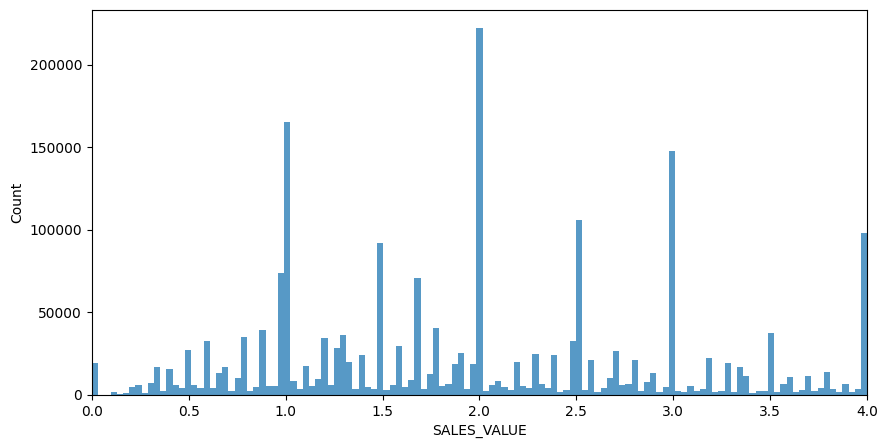

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(transactions['SALES_VALUE'])
plt.xlim(0, 4)
plt.show()

In [11]:
transactions['SALES_VALUE'].describe()

count    2.595732e+06
mean     3.104120e+00
std      4.182274e+00
min      0.000000e+00
25%      1.290000e+00
50%      2.000000e+00
75%      3.490000e+00
max      8.400000e+02
Name: SALES_VALUE, dtype: float64

In [12]:
transactions['SALES_VALUE'].quantile(0.8)

np.float64(3.99)

In [13]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [14]:
transactions.groupby('BASKET_ID')['QUANTITY'].sum().value_counts()

QUANTITY
1        30733
2        27537
3        21784
4        17666
5        14343
         ...  
15473        1
23739        1
11268        1
10761        1
19932        1
Name: count, Length: 11894, dtype: int64

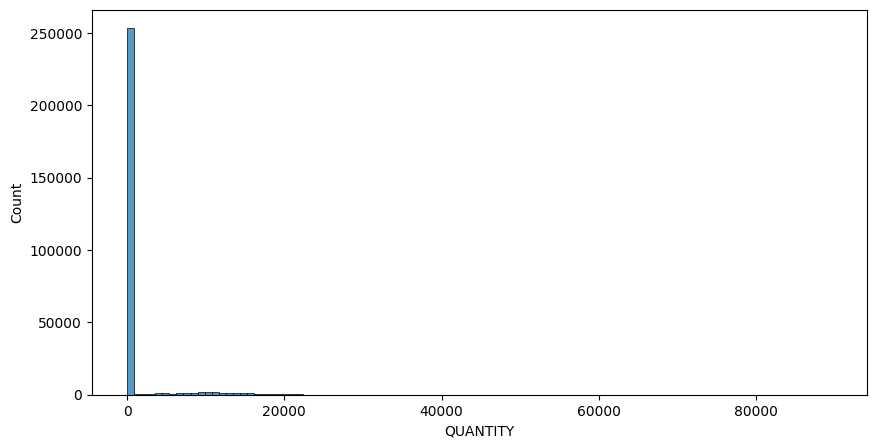

In [15]:
basket_size = transactions.groupby('BASKET_ID')['QUANTITY'].sum()
plt.figure(figsize=(10, 5))
sns.histplot(basket_size, bins=100)
plt.show()

In [16]:
transactions['WEEK_NO'].value_counts()

WEEK_NO
92    33126
99    32256
42    31454
68    31423
59    31276
      ...  
5      7168
4      5379
3      4803
2      3675
1      1881
Name: count, Length: 102, dtype: int64

In [17]:
transactions.groupby('household_key')['BASKET_ID'].nunique().sort_values(ascending=False)

household_key
1510    1300
900     1223
2337    1210
1795    1138
2459     971
        ... 
379        2
1626       2
494        1
1830       1
1897       1
Name: BASKET_ID, Length: 2500, dtype: int64

In [18]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [19]:
len(transactions[transactions['household_key'] == 1510])

4813

In [20]:
transactions.groupby('PRODUCT_ID')['QUANTITY'].sum().sort_values(ascending=False)

PRODUCT_ID
6534178     216532156
6533889      18479630
6534166      13980451
6544236       2705127
1404121       1694604
              ...    
17290773            0
1037632             0
17320080            0
17329056            0
17330118            0
Name: QUANTITY, Length: 92339, dtype: int64

In [21]:
product[product['PRODUCT_ID'] == 6534178].head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [22]:
transactions.groupby('PRODUCT_ID')['SALES_VALUE'].sum().sort_values(ascending=False)

PRODUCT_ID
6534178     503867.11
6533889      46311.32
1029743      41072.06
6534166      33594.48
1082185      29482.00
              ...    
8068920          0.00
7127001          0.00
10254376         0.00
10250723         0.00
13416321         0.00
Name: SALES_VALUE, Length: 92339, dtype: float64

#### EDA - II

In [23]:
df2 = pd.merge(transactions, product, how='left', on='PRODUCT_ID')

In [24]:
df2.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB


In [25]:
df2.isnull().sum()

household_key           0
BASKET_ID               0
DAY                     0
PRODUCT_ID              0
QUANTITY                0
SALES_VALUE             0
STORE_ID                0
RETAIL_DISC             0
TRANS_TIME              0
WEEK_NO                 0
COUPON_DISC             0
COUPON_MATCH_DISC       0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64

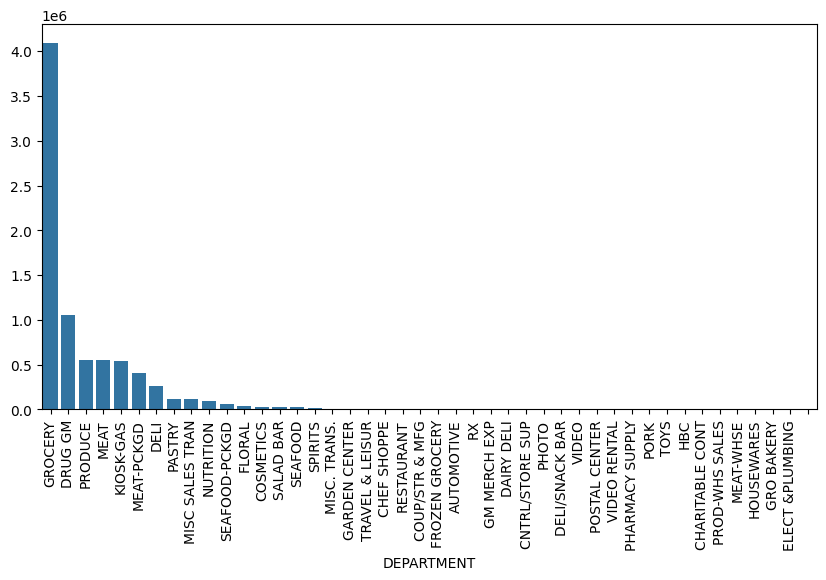

In [26]:
sales_by_dept = df2.groupby('DEPARTMENT')['SALES_VALUE'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_dept.index, y=sales_by_dept.values)
plt.xticks(rotation=90)
plt.show()


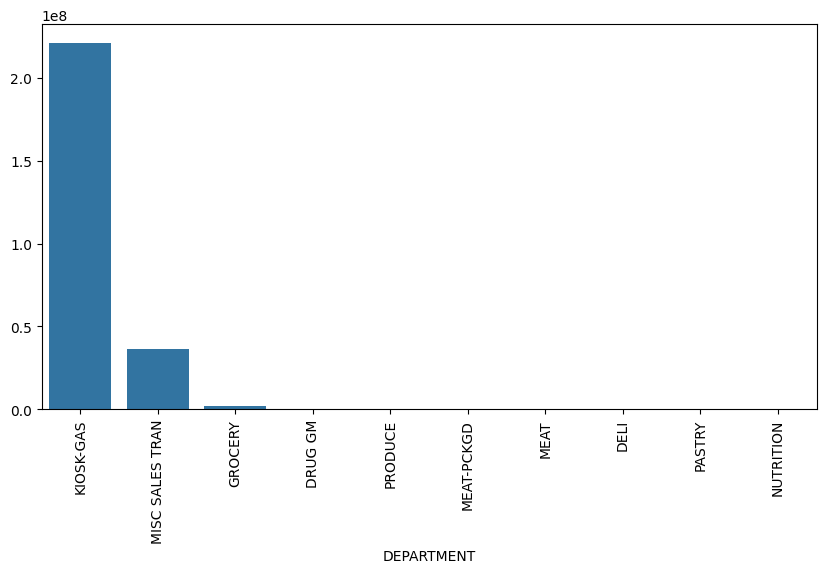

In [27]:
sales_by_dept = df2.groupby('DEPARTMENT')['QUANTITY'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_dept.index, y=sales_by_dept.values)
plt.xticks(rotation=90)
plt.show()

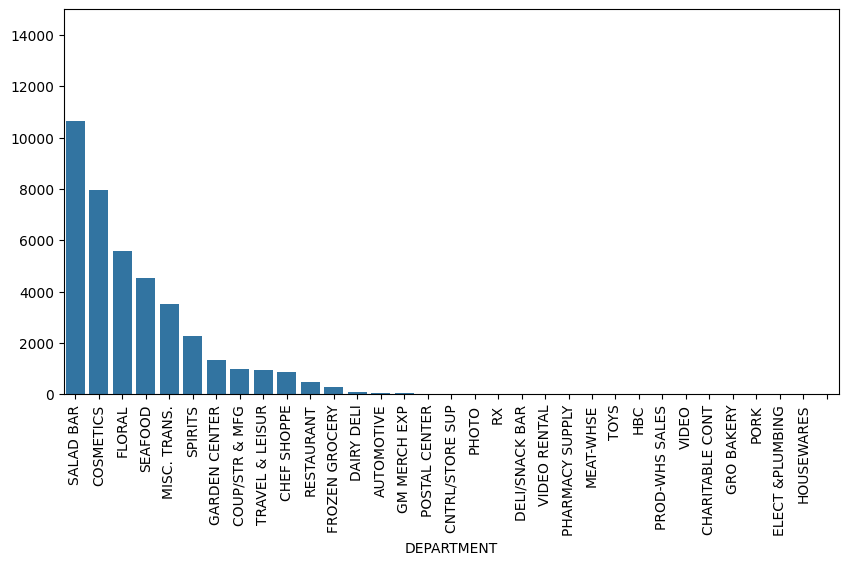

In [28]:
sales_by_dept = df2.groupby('DEPARTMENT')['QUANTITY'].sum().sort_values(ascending=False).iloc[11:]
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_dept.index, y=sales_by_dept.values)
plt.ylim(0,15000)
plt.xticks(rotation=90)
plt.show()


In [29]:
df2.groupby('DEPARTMENT')['QUANTITY'].sum().sort_values(ascending=False)

DEPARTMENT
KIOSK-GAS          221254887
MISC SALES TRAN     36080860
GROCERY              2194762
DRUG GM               353844
PRODUCE               319993
MEAT-PCKGD            148148
MEAT                  119113
DELI                   67026
PASTRY                 49820
NUTRITION              43253
SEAFOOD-PCKGD          14003
SALAD BAR              10659
COSMETICS               7984
FLORAL                  5586
SEAFOOD                 4555
MISC. TRANS.            3520
SPIRITS                 2290
GARDEN CENTER           1336
COUP/STR & MFG          1011
TRAVEL & LEISUR          950
CHEF SHOPPE              875
RESTAURANT               504
FROZEN GROCERY           297
DAIRY DELI                77
AUTOMOTIVE                67
GM MERCH EXP              54
POSTAL CENTER             28
CNTRL/STORE SUP           22
PHOTO                     19
RX                        15
DELI/SNACK BAR            12
VIDEO RENTAL              11
PHARMACY SUPPLY            8
MEAT-WHSE                  7
TOY

In [30]:
df2.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB


In [31]:
transactions.groupby('STORE_ID')['SALES_VALUE'].sum().sort_values(ascending=False)

STORE_ID
367     267614.34
406     216781.77
361     144698.85
429     142391.01
343     140455.75
          ...    
765          1.00
639          0.85
256          0.76
610          0.50
1235         0.00
Name: SALES_VALUE, Length: 582, dtype: float64

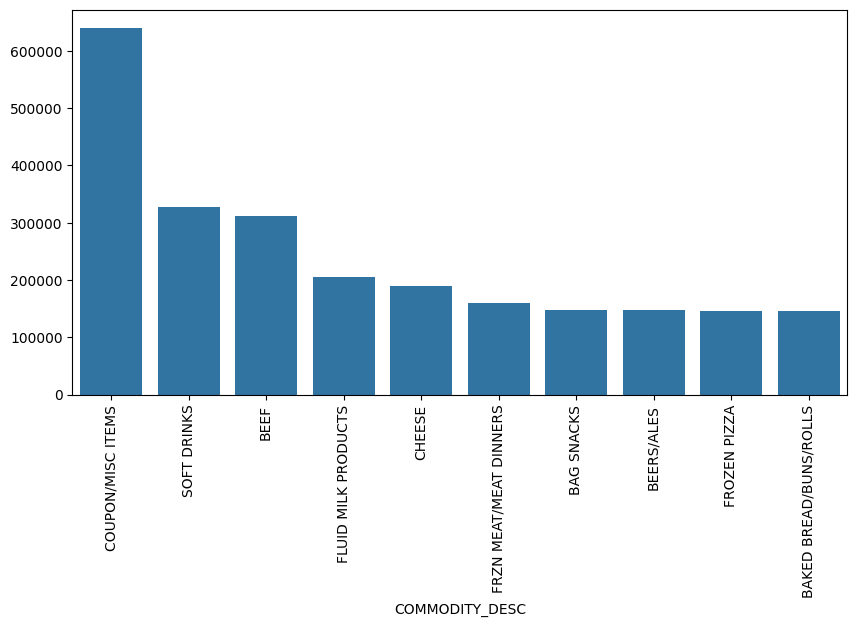

In [32]:
sales_by_comm = df2.groupby('COMMODITY_DESC')['SALES_VALUE'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_comm.index, y=sales_by_comm.values)
plt.xticks(rotation=90)
plt.show()


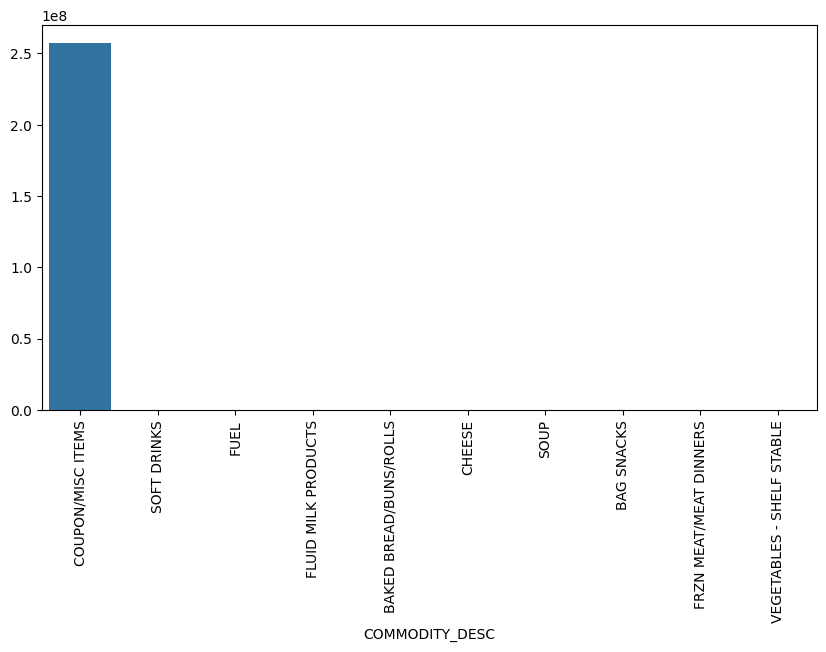

In [33]:
sales_by_comm = df2.groupby('COMMODITY_DESC')['QUANTITY'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_comm.index, y=sales_by_comm.values)
plt.xticks(rotation=90)
plt.show()

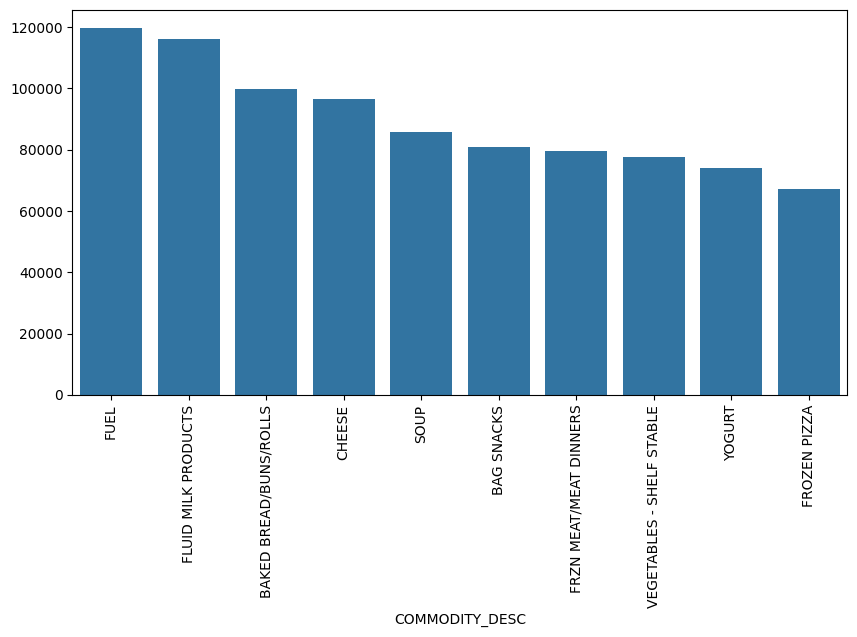

In [34]:
sales_by_comm = df2.groupby('COMMODITY_DESC')['QUANTITY'].sum().sort_values(ascending=False).iloc[2:12]
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_comm.index, y=sales_by_comm.values)
plt.xticks(rotation=90)
plt.show()

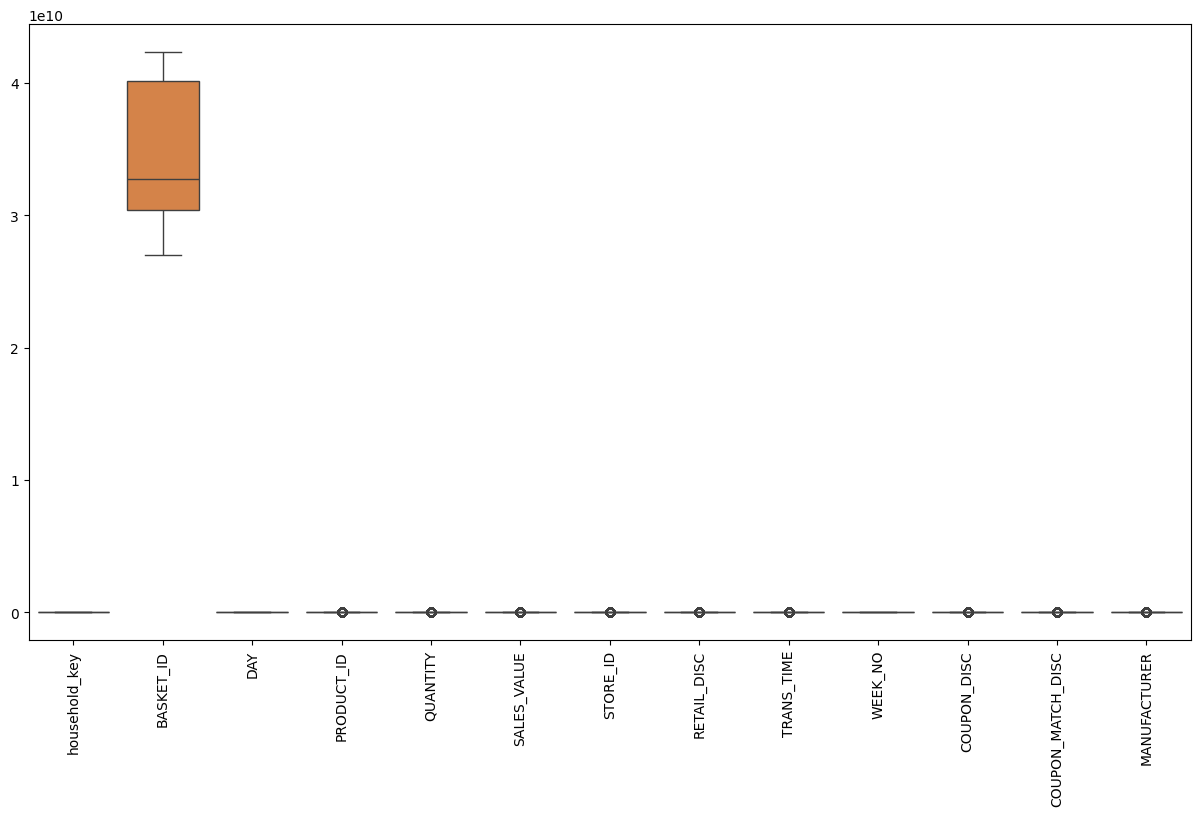

In [35]:
# fit kmeans
num_dtypes = df2.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 8))
sns.boxplot(data=df2[num_dtypes])
plt.xticks(rotation=90)
plt.show()

In [36]:
df2.to_csv('merged_transactions_product.csv', index=False)